# Project: Convolutional Neural Networks

In [1]:
import torch
# setting device on GPU if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()

#Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

Using device: cuda

Tesla T4


## Introduction

For this project we will implement one of the most commonly used model for image recognition tasks, the Residual Network. The architecture is introduced in 2015 by Kaiming He, et al. in the paper ["Deep residual learning for image recognition"](https://www.cv-foundation.org/openaccess/content_cvpr_2016/papers/He_Deep_Residual_Learning_CVPR_2016_paper.pdf).
<br>

In a residual network, each block contains some convolutional layers, plus "skip" connections, which allow the activations to by pass a layer, and then be summed up with the activations of the skipped layer. The image below illustrates a building block in residual networks.

In this part, we will use basic pytorch operations to define the 2D convolution, max pooling operation, linear layer as well as 2d batch normalization.

In [ ]:
import torch
import torch.nn as nn
import sys
import numpy as np

class Conv2d(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 kernel_size,
                 stride=1,
                 padding=0,
                 bias=True):

        super(Conv2d, self).__init__()
        """
        An implementation of a convolutional layer.

        The input consists of N data points, each with C channels, height H and
        width W. We convolve each input with F different filters, where each filter
        spans all C channels and has height HH and width WW.

        Parameters:
        - w: Filter weights of shape (F, C, HH, WW)
        - b: Biases, of shape (F,)
        - kernel_size: Size of the convolving kernel
        - stride: The number of pixels between adjacent receptive fields in the
            horizontal and vertical directions.
        - padding: The number of pixels that will be used to zero-pad the input.
        """

        self.padding = padding

        self.in_channels = in_channels
        self.out_channels = out_channels

        if isinstance(kernel_size, int):
            kernel_size = (kernel_size, kernel_size)
        self.kernel_size = kernel_size

        if isinstance(stride, int):
            stride = (stride, stride)
        self.stride = stride

        assert isinstance(in_channels, int) and in_channels > 0
        assert isinstance(out_channels, int) and out_channels > 0
        assert isinstance(kernel_size, tuple) and all(k > 0 for k in kernel_size)
        assert isinstance(stride, tuple) and all(s > 0 for s in stride)
        assert isinstance(padding, int) and padding >= 0


        self.w = torch.randn(out_channels, in_channels, kernel_size[0], kernel_size[1], requires_grad=True)

        if bias:
            self.b = torch.randn(out_channels, requires_grad=True)
        else:
            self.b = None

    def forward(self, x):
        """
        Input:
        - x: Input data of shape (N, C, H, W)
        Output:
        - out: Output data, of shape (N, F, H', W').
        """



        # Dimensions of kernel and input image
        N_x, C_x, H_x, W_x = x.shape
        F, C, HH, WW = self.w.shape
        assert C_x == C
        stride_h, stride_w = self.stride

        h_out =(H_x + 2 * self.padding - HH) // stride_h + 1
        w_out =(W_x + 2 * self.padding - WW) // stride_w + 1


        # Defining unfolding parameters
        unfold_params = dict(kernel_size=self.kernel_size, padding=self.padding, stride=self.stride)

        # Creating unfolding module
        def unfold(x, kernel_size, stride, padding):
            N, C, H, W = x.shape
            KH, KW = kernel_size
            stride_h, stride_w = stride

            if padding > 0:
                padded_x = torch.zeros(N, C, H + 2 * padding, W + 2 * padding)
                padded_x[:, :, padding:H + padding, padding:W + padding] = x
            else:
                padded_x = x

            unfolded = []
            for i in range(0, H + 2 * padding - KH + 1, stride_h):
                for j in range(0, W + 2 * padding - KW + 1, stride_w):
                    patch = padded_x[:, :, i:i + KH, j:j + KW]
                    unfolded.append(patch.reshape(N, C * KH * KW))

            return torch.stack(unfolded, dim=-1)

        # Unfolding the input
        inp_unf = unfold(x, **unfold_params)

        # Adapt weigh tensor
        w = self.w.view(self.w.size(0), -1)

        out_unf = torch.matmul(w, inp_unf)
        # Folding back to Pytorch tensor shape
        out = out_unf.view(N_x,F,h_out,w_out)
        if self.b is not None:
            out += self.b.view(1, F, 1, 1)

        return out


In [ ]:
class MaxPool2d(nn.Module):
    def __init__(self, kernel_size):
        super(MaxPool2d, self).__init__()
        """
        An implementation of a max-pooling layer.

        Parameters:
        - kernel_size: the size of the window to take a max over
        """
        if isinstance(kernel_size, int):
            kernel_size = (kernel_size, kernel_size)
        self.kernel_size = kernel_size


        self.stride = self.kernel_size

    def forward(self, x):
        """
        Input:
        - x: Input data of shape (N, C, H, W)
        Output:
        - out: Output data, of shape (N, F, H', W').
        """

        if (len(x.shape)!=4):
            raise ValueError('the input data shape should be:\n' +
                             '2d conv: (batch size, # of features, height, width)'
                            )

        # Dimensions of kernel and input image
        N_x, C_x, H_x, W_x = x.shape
        HH,WW = self.kernel_size
        stride_h, stride_w = self.stride

        h_out = (H_x - HH) // stride_h + 1
        w_out = (W_x - WW) // stride_w + 1


        # Defining folding parameters
        unfold_params = dict(kernel_size=self.kernel_size, stride=self.stride)

        # Creating unfolding and folding modules
        def unfold(x, kernel_size, stride):
            N, C, H, W = x.shape
            KH, KW = kernel_size
            stride_h, stride_w = stride
            unfolded = []
            for i in range(0, H- KH + 1, stride_h):
                for j in range(0, W - KW + 1, stride_h):
                    patch = x[:, :, i:i + KH, j:j + KW]
                    unfolded.append(patch.reshape(N, C, -1))
            return torch.stack(unfolded, dim = -1).view(N, C, KH * KW, -1)
        def fold(unfolded, h_out, w_out):
            N, C, L = unfolded.shape
            return unfolded.reshape(N, C, h_out, w_out)

        # Unfolding the input
        inp_unf = unfold(x, ** unfold_params)

        out_unf =inp_unf.max(dim=2)[0]


        # Folding back the tensor
        out = fold(out_unf,h_out,w_out)

        return out

In [ ]:
class Linear(nn.Module):
    def __init__(self, in_channels, out_channels, bias=True):
        super(Linear, self).__init__()
        """
        An implementation of a Linear layer.

        Parameters:
        - weight: the learnable weights of the module of shape (in_channels, out_channels).
        - bias: the learnable bias of the module of shape (out_channels).
        """
        self.in_channels = in_channels
        self.out_channels = out_channels

        self.weight = torch.randn(in_channels, out_channels, requires_grad=True)
        if bias:
            self.bias = torch.randn(out_channels, requires_grad=True)
        else:
            self.bias = None

        self.bias_flag = bias

    def forward(self, x):
        """
        Input:
        - x: Input data of shape (N, *, H) where * means any number of additional
        dimensions and H = in_channels
        Output:
        - out: Output data of shape (N, *, H') where * means any number of additional
        dimensions and H' = out_channels
        """

        assert x.shape[-1] == self.in_channels

        out = x.matmul(self.weight)
        if self.bias_flag:
            out += self.bias

        return out

In [ ]:
class BatchNorm2d(nn.Module):
    def __init__(self, num_features, eps=1e-05, momentum=0.1):
        super(BatchNorm2d, self).__init__()
        """
        An implementation of a Batch Normalization over a mini-batch of 2D inputs.

        The mean and standard-deviation are calculated per-dimension over the
        mini-batches and gamma and beta are learnable parameter vectors of
        size num_features.

        Parameters:
        - num_features: C from an expected input of size (N, C, H, W).
        - eps: a value added to the denominator for numerical stability. Default: 1e-5
        - momentum: momentum – the value used for the running_mean and running_var
        computation. Default: 0.1
        - gamma: the learnable weights of shape (num_features).
        - beta: the learnable bias of the module of shape (num_features).
        """

        self.num_features = num_features
        self.eps = eps
        self.momentum = momentum

        self.register_buffer('running_mean', torch.zeros(num_features))
        self.register_buffer('running_var', torch.ones(num_features))

        self.running_mean = torch.zeros(num_features)
        self.running_var = torch.ones(num_features)

        self.gamma = torch.ones(num_features, requires_grad = True)
        self.beta = torch.zeros(num_features, requires_grad= True)

    def forward(self, x):
        """
        During training this layer keeps running estimates of its computed mean and
        variance, which are then used for normalization during evaluation.
        Input:
        - x: Input data of shape (N, C, H, W)
        Output:
        - out: Output data of shape (N, C, H, W) (same shape as input)
        """

        N, C, H, W =x.shape

        mean = x.mean(dim=(0, 2, 3), keepdim=True)

        variance = x.var(dim=(0, 2, 3), keepdim=True, unbiased=False)

        # If in training mode
        if self.train:

            X_hat = (x - mean) / torch.sqrt(variance + self.eps)

            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * mean.squeeze()

            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * variance.squeeze()

        # If in testing mode
        else:
             X_hat = (x - self.running_mean.view(1, C, 1, 1)) / torch.sqrt(self.running_var.view(1, C, 1, 1) + self.eps)

        x = self.gamma.view(1, C, 1, 1) * X_hat + self.beta.view(1, C, 1, 1)

        return x

## TESTING ALGORITHM
Below I provide the code I used for testing the functions.  


Saving img.png to img (4).png
Conv2d: True
MaxPooling2d: True
FC: True

All parameters are equal!

All parameters are equal!

All parameters are equal!



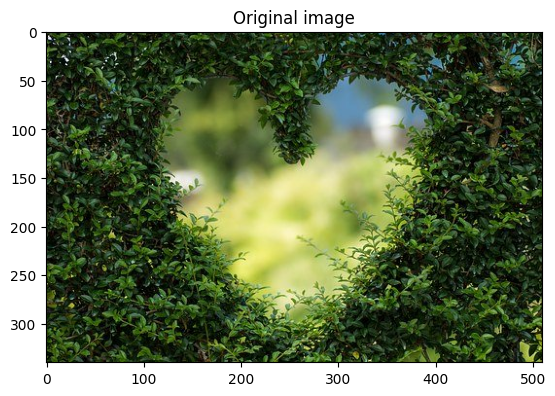

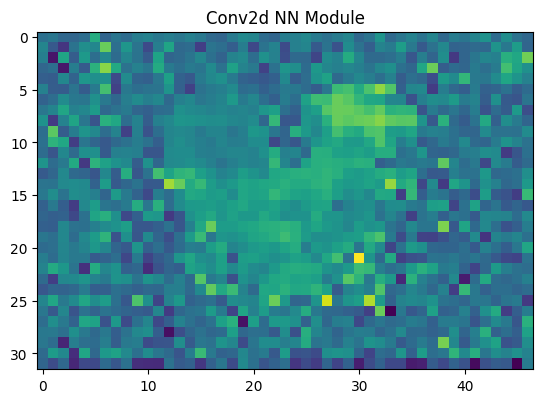

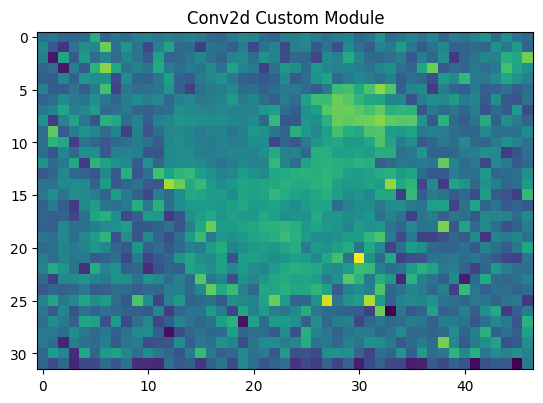

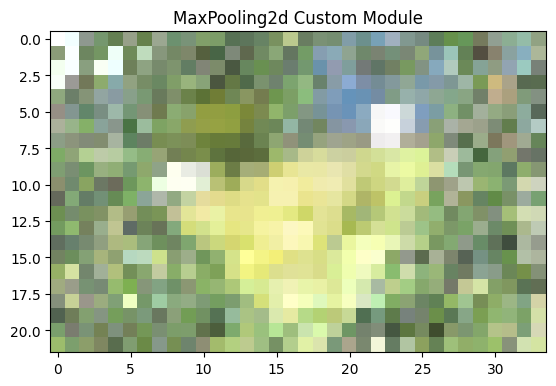

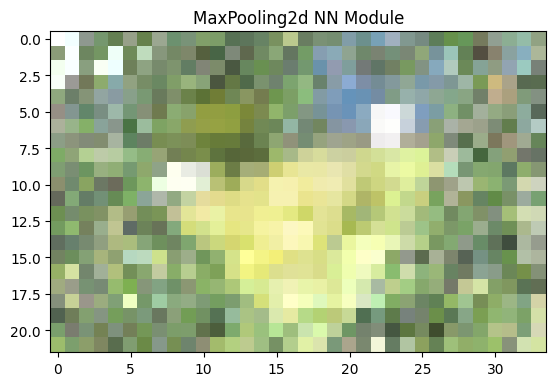

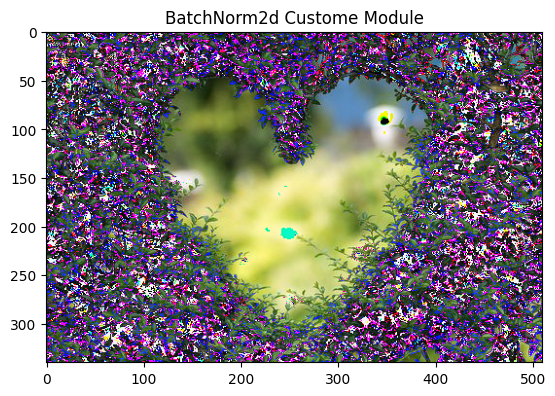

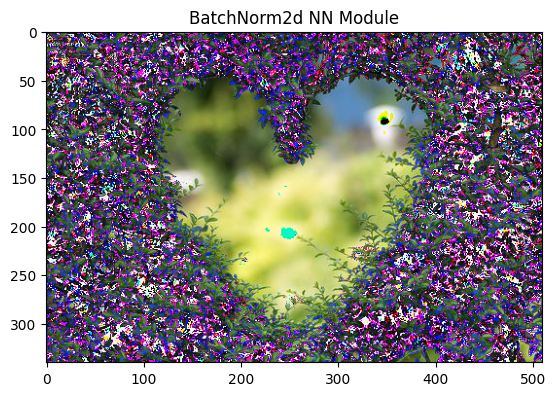

In [26]:
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from google.colab import files

uploaded = files.upload()

# Get the uploaded file name
filename = list(uploaded.keys())[0]
img = Image.open(filename)
image = transforms.ToTensor()(img).unsqueeze_(0)
plt.figure(1)
plt.title("Original image")
plt.imshow(img)

# Conv2d Test

# Parameters
kernel_size = 5
stride = 11
padding = 4
filters = 5
bias = True

#torch.manual_seed(1)

# Initialising custom and nn instances
conv2d = Conv2d(3, filters, kernel_size, padding = padding, stride=stride,bias=bias)
conv2d_py = torch.nn.Conv2d(3, filters, kernel_size, padding = padding,stride=stride,bias=bias)

# Copying weights from nn to costum module
conv2d.w = conv2d_py.weight.data
conv2d.b = conv2d_py.bias.data

# Performing convolution using nn module
out_py = conv2d_py(image)
plt.figure()
plt.title("Conv2d NN Module")
plt.imshow(out_py[0,0,:,:].detach().numpy())

# Performing convolution using custom module
out = conv2d.forward(image)
plt.figure()
plt.title("Conv2d Custom Module")
plt.imshow(out[0,0,:,:].detach().numpy())


# Checking if outputs are the same
print("Conv2d: {}".format(torch.allclose(out_py,out,atol=1e-06)))



# MaxPooling test


# Max-pooling kernel size
kernel_size = 15

torch.manual_seed(1)

# Initialising custom and nn modules
maxpool2d = MaxPool2d(kernel_size)
maxpool2d_py = torch.nn.MaxPool2d(kernel_size)

# Performing maxPooling on the image
out = maxpool2d.forward(image)
out_py = maxpool2d_py.forward(image)

# Plotting custome module result
plt.figure()
plt.title("MaxPooling2d Custom Module")
tensor_image = transforms.ToPILImage()(out.squeeze(0))
plt.imshow(tensor_image)

# Plotting nn module result
plt.figure()
plt.title("MaxPooling2d NN Module")
tensor_image = transforms.ToPILImage()(out_py.squeeze(0))
plt.imshow(tensor_image)

# Checking if the outputs are equal
print("MaxPooling2d: {}".format(torch.allclose(out_py,out,atol=1e-06)))


# Linear test


# Parameters
in_channels = 510
out_channels = 10
bias = True

torch.manual_seed(1)

# Initialising custom and nn modules
linear = Linear(in_channels,out_channels,bias)
linear_py = torch.nn.Linear(in_channels,out_channels,bias)

# Copying weights and bias from nn to costume module
linear.weight = linear_py.weight.t()
linear.bias = linear_py.bias

# Forward pass
out = linear.forward(image)
out_py = linear_py.forward(image)

# Checking if outputs are the same
print("FC: {}".format(torch.allclose(out_py,out,atol=1e-06)))
print()


# BM Testing


# Function comparing all the different data structures in the module
def compare_bn(bn1, bn2):
    err = False
    if not torch.allclose(bn1.running_mean, bn2.running_mean,atol=1e-07):
        print('Diff in running_mean: {} vs {}'.format(
            bn1.running_mean, bn2.running_mean))
        err = True

    if not torch.allclose(bn1.running_var, bn2.running_var,atol=1e-07):
        print('Diff in running_var: {} vs {}'.format(
            bn1.running_var, bn2.running_var))
        err = True

    if not torch.allclose(bn1.gamma, bn2.weight,atol=1e-07):
        print('Diff in weight: {} vs {}'.format(
            bn1.gamma, bn2.weight))
        err = True

    if not torch.allclose(bn1.beta, bn2.bias,atol=1e-07):
        print('Diff in bias: {} vs {}'.format(
            bn1.beta, bn2.bias))
        err = True

    if not err:
        print('All parameters are equal!')


# Parameters
num_features = 3
eps=1e-05
momentum=0.1

# Initialising custom and nn modules
bn = BatchNorm2d(num_features,eps=eps,momentum=momentum)
bn_py = nn.BatchNorm2d(num_features,eps=eps,momentum=momentum)

# Performing a forward pass in train mode
img_bn = bn.forward(image)
img_bn_py = bn_py(image)

# Comparing data structure values after 1 run
compare_bn(bn,bn_py)
print()

# Performing a second forward pass in train mode
img_bn = bn.forward(image)
img_bn_py = bn_py(image)

# Comparing data structure values after 2 runs
compare_bn(bn,bn_py)
print()

# Setting both modules to testing mode
bn.train=False
bn_py.eval()

# Performing a third forward pass in test mode
img_bn = bn.forward(image)
img_bn_py = bn_py(image)

# Comparing data structure values after 3 runs
compare_bn(bn,bn_py)
print()

# Plot the results from the custom module
plt.figure()
plt.title("BatchNorm2d Custome Module")
tensor_image = transforms.ToPILImage()(img_bn.squeeze(0))
plt.imshow(tensor_image)

# Plot the results from the nn module
plt.figure()
plt.title("BatchNorm2d NN Module")
tensor_image = transforms.ToPILImage()(img_bn_py.squeeze(0))
plt.imshow(tensor_image)




In this part, we will train a ResNet-18 defined on the CIFAR-10 dataset.Our goal is to maximise the performance of your model by tuning the hyper-parameters and applying data augmentation. We use limited number of training epochs due to computational expenses

In [27]:
import torch
from torch.nn import Conv2d, MaxPool2d
import torch.nn as nn
import torch.nn.functional as F

Next, we define ResNet-18:

In [28]:
# define resnet building blocks

class ResidualBlock(nn.Module):
    def __init__(self, inchannel, outchannel, stride=1):

        super(ResidualBlock, self).__init__()

        self.left = nn.Sequential(Conv2d(inchannel, outchannel, kernel_size=3,
                                         stride=stride, padding=1, bias=False),
                                  nn.BatchNorm2d(outchannel),
                                  nn.ReLU(inplace=True),
                                  Conv2d(outchannel, outchannel, kernel_size=3,
                                         stride=1, padding=1, bias=False),
                                  nn.BatchNorm2d(outchannel))

        self.shortcut = nn.Sequential()

        self.lrelu = nn.LeakyReLU()

        if stride != 1 or inchannel != outchannel:

            self.shortcut = nn.Sequential(Conv2d(inchannel, outchannel,
                                                 kernel_size=1, stride=stride,
                                                 padding = 0, bias=False),
                                          nn.BatchNorm2d(outchannel) )

    def forward(self, x):

        out = self.left(x)

        out += self.shortcut(x)

        out = self.lrelu(out)

        return out



    # define resnet

class ResNet(nn.Module):

    def __init__(self, ResidualBlock, num_classes = 10,fc2=False,nodes_fc2=10,extra_block=False):

        super(ResNet, self).__init__()

        self.extra_block = extra_block

        self.fc2_on = fc2
        self.nodes_fc2 = nodes_fc2

        self.inchannel = 64
        self.conv1 = nn.Sequential(Conv2d(3, 64, kernel_size = 3, stride = 1,
                                            padding = 1, bias = False),
                                  nn.BatchNorm2d(64),
                                  nn.ReLU())

        self.layer1 = self.make_layer(ResidualBlock, 64, 2, stride = 1)
        self.layer2 = self.make_layer(ResidualBlock, 128, 2, stride = 2)
        self.layer3 = self.make_layer(ResidualBlock, 256, 2, stride = 2)
        self.layer4 = self.make_layer(ResidualBlock, 512, 2, stride = 2)

        if self.extra_block:
            self.layer5 = self.make_layer(ResidualBlock, 1024, 2, stride = 1)

        self.maxpool = MaxPool2d(4)

        if self.extra_block:

            if self.fc2_on:
                self.fc1_e = nn.Linear(1024, self.nodes_fc2)
                self.fc2_e = nn.Linear(self.nodes_fc2, num_classes)
            else:
                self.fc_e = nn.Linear(1024, num_classes)


        else:
            if self.fc2_on:
                self.fc1 = nn.Linear(512, self.nodes_fc2)
                self.fc2 = nn.Linear(self.nodes_fc2, num_classes)
            else:

                self.fc = nn.Linear(512, num_classes)


    def make_layer(self, block, channels, num_blocks, stride):

        strides = [stride] + [1] * (num_blocks - 1)

        layers = []

        for stride in strides:

            layers.append(block(self.inchannel, channels, stride))

            self.inchannel = channels

        return nn.Sequential(*layers)


    def forward(self, x):

        x = self.conv1(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        if self.extra_block:

            x = self.layer5(x)

            x = self.maxpool(x)

            x = x.reshape(x.size(0), -1)

            if self.fc2_on:

                x = self.fc1_e(x)
                x = self.fc2_e(x)

            else:
                x = self.fc_e(x)


        else:

            x = self.maxpool(x)

            x = x.reshape(x.size(0), -1)


            if self.fc2_on:

                x = self.fc1(x)
                x = self.fc2(x)

            else:
                x = self.fc(x)


        return x


def ResNet18(fc2,nodes_fc2,extra_block):
    return ResNet(ResidualBlock,fc2=fc2,nodes_fc2=nodes_fc2,extra_block=extra_block)

### Loading dataset
We will import images from the [torchvision.datasets](https://pytorch.org/vision/main/datasets.html) library <br>
First, we need to define the alterations (transforms) we want to perform to our images - given that transformations are applied when importing the data. <br>
Define the following transforms using the torchvision.datasets library -- you can read the transforms documentation [here](https://pytorch.org/vision/stable/transforms.html): <br>
1. Convert images to tensor
2. Normalize mean and std of images with values:mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010]

In [ ]:

import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import sampler

import torchvision.datasets as dset

import numpy as np

import torchvision.transforms as T

def GetData(train):

    transforms = T.Compose([
        T.RandomHorizontalFlip(),
        #T.RandomRotation(degrees=2.5),
        #T.RandomAffine(degrees=0.2, translate=(0.1, 0.1)),
        T.ToTensor(),
        #T.RandomErasing(p=0.3, scale=(0.3, 03), ratio=(0.2, 3.2)),
        T.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.35, hue=0.2),
        T.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
    ])

    data = dset.CIFAR10('./data', train=train, transform=transforms, download=True)

    return data



Now load the dataset using the transform you defined above<br>
You can check the documentation [here](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html).
Then create data loaders (using DataLoader from torch.utils.data) for the training and test set

In [ ]:
train_dataset = GetData(train=True)
test_dataset = GetData(train=False)
loader_train = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
loader_test = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

100%|██████████| 170498071/170498071 [00:12<00:00, 13372698.30it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


In [31]:
from torch.optim.lr_scheduler import CosineAnnealingLR
USE_GPU = True
dtype = torch.float32

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')


print_every = 100
def check_accuracy(loader, model):
    # function for test accuracy on validation and test set

    if loader.dataset.train:
        print('Checking accuracy on validation set')
    else:
        print('Checking accuracy on test set')
    num_correct = 0
    num_samples = 0
    model.eval()  # set model to evaluation mode
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)  # move to device
            y = y.to(device=device, dtype=torch.long)
            scores = model(x)
            _, preds = scores.max(1)
            num_correct += (preds == y).sum()
            num_samples += preds.size(0)
        acc = float(num_correct) / num_samples
        print('Got %d / %d correct (%.2f)' % (num_correct, num_samples, 100 * acc))



def train_part(model, optimizer,scheduler, epochs=1):
    """
    Train a model on CIFAR-10 using the PyTorch Module API.

    Inputs:
    - model: A PyTorch Module giving the model to train.
    - optimizer: An Optimizer object we will use to train the model
    - epochs: (Optional) A Python integer giving the number of epochs to train for

    Returns: Nothing, but prints model accuracies during training.
    """
    model = model.to(device=device)  # move the model parameters to CPU/GPU
    for e in range(epochs):
      print(f"Starting epoch {e+1} / {epochs}")
      print(f"Learning Rate at the start of epoch: {scheduler.get_last_lr()[0]:.6f}")
      for t, (x, y) in enumerate(loader_train):
            model.train()  # put model to training mode
            x = x.to(device=device, dtype=dtype)  # move to device, e.g. GPU
            y = y.to(device=device, dtype=torch.long)

            scores = model(x)
            loss = F.cross_entropy(scores, y)

            # Zero out all of the gradients for the variables which the optimizer
            # will update.
            optimizer.zero_grad()

            loss.backward()

            # Update the parameters of the model using the gradients
            optimizer.step()

            if t % print_every == 0:
                print('Epoch: %d, Iteration %d, loss = %.4f' % (e, t, loss.item()))

      scheduler.step()
      print(f"Learning Rate after epoch {e+1}: {scheduler.get_last_lr()[0]:.6f}")

In [ ]:
fc2 = False
nodes_fc2 = 128
extra_block = False
model = ResNet18(fc2 = fc2, nodes_fc2 = nodes_fc2, extra_block = extra_block)
print(model)

lr = 5e-4
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)

scheduler = CosineAnnealingLR(optimizer, T_max=10)

train_part(model, optimizer,scheduler, epochs = 10)


check_accuracy(loader_test, model)

torch.save(model.state_dict(), 'model.pt')

ResNet(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer1): Sequential(
    (0): ResidualBlock(
      (left): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (shortcut): Sequential()
      (lrelu): LeakyReLU(negative_slope=0.01)
    )
    (1): ResidualBlock(
      (left): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, t

<ipython-input-33-7e34aa770430>:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model.pt"))


ResNet(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer1): Sequential(
    (0): ResidualBlock(
      (left): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (shortcut): Sequential()
      (lrelu): LeakyReLU(negative_slope=0.01)
    )
    (1): ResidualBlock(
      (left): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, t

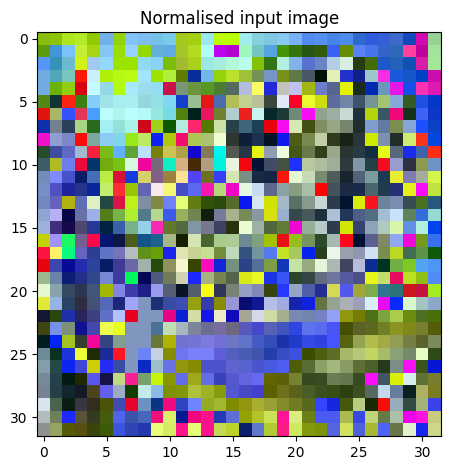

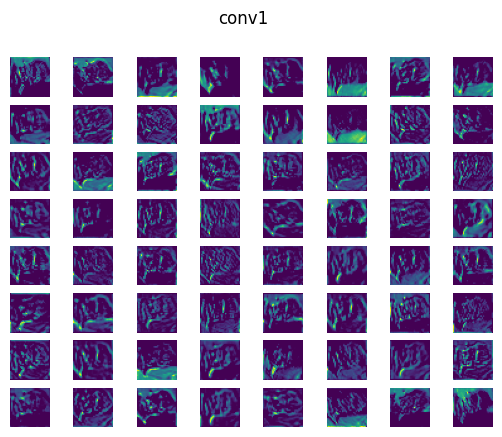

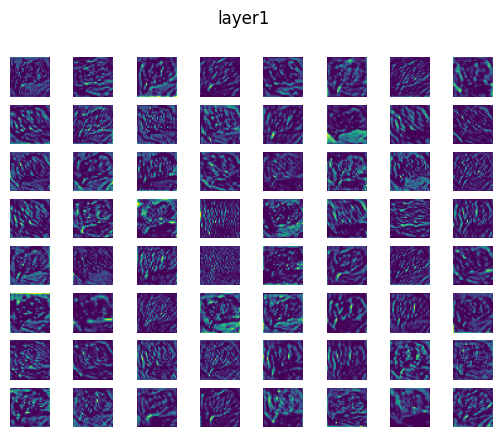

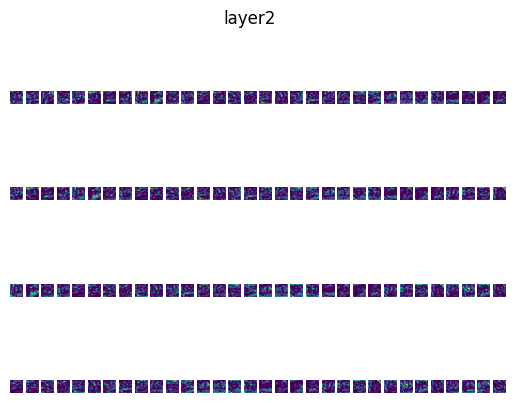

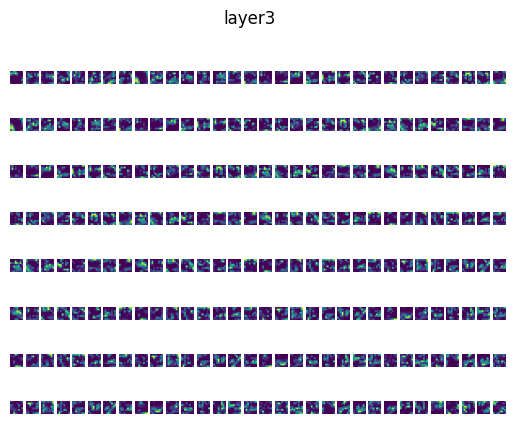

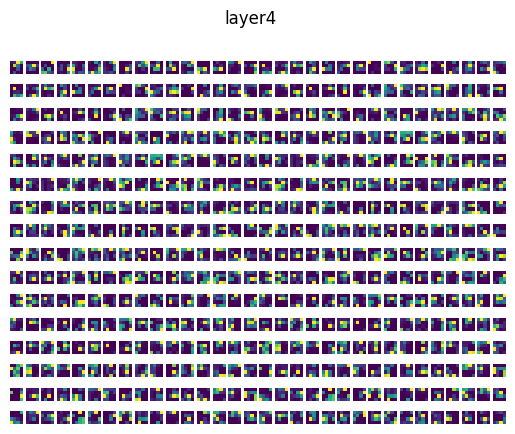

In [33]:
import matplotlib.pyplot as plt
import torch
from torchvision import transforms


dtype = torch.float32
USE_GPU = True

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')


model = ResNet18(fc2=fc2,nodes_fc2=nodes_fc2,extra_block=extra_block)
model = model.to(device=device)
model.load_state_dict(torch.load("model.pt"))
model.eval()

print(model)



activation = {}
def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

vis_labels = ['conv1', 'layer1', 'layer2', 'layer3', 'layer4']

for l in vis_labels:

    getattr(model, l).register_forward_hook(get_activation(l))


data_dir = './data'
mean = (0.4914, 0.4822, 0.4465)
std = (0.2023, 0.1994, 0.2010)

data = GetData(train=False)[0][0]
data = data.unsqueeze(0).to(device=device, dtype=dtype)
#data = GetData(data_dir,False,mean,std,normalise = False)[0][0]
#data = data.unsqueeze(0).to(device = device, dtype = dtype)

plt.figure()
plt.title("Normalised input image")
img = transforms.ToPILImage()(data.cpu().squeeze(0))
plt.imshow(img)

output = model(data)


plt.tight_layout()

for idx, l in enumerate(vis_labels):

    act = activation[l].squeeze()

    if idx < 2:
        ncols = 8
    else:
        ncols = 32

    nrows = act.size(0) // ncols

    fig, axarr = plt.subplots(nrows, ncols)
    fig.suptitle(l)


    for i in range(nrows):
        for j in range(ncols):
            axarr[i, j].imshow(act[i * nrows + j].cpu())
            axarr[i, j].axis('off')

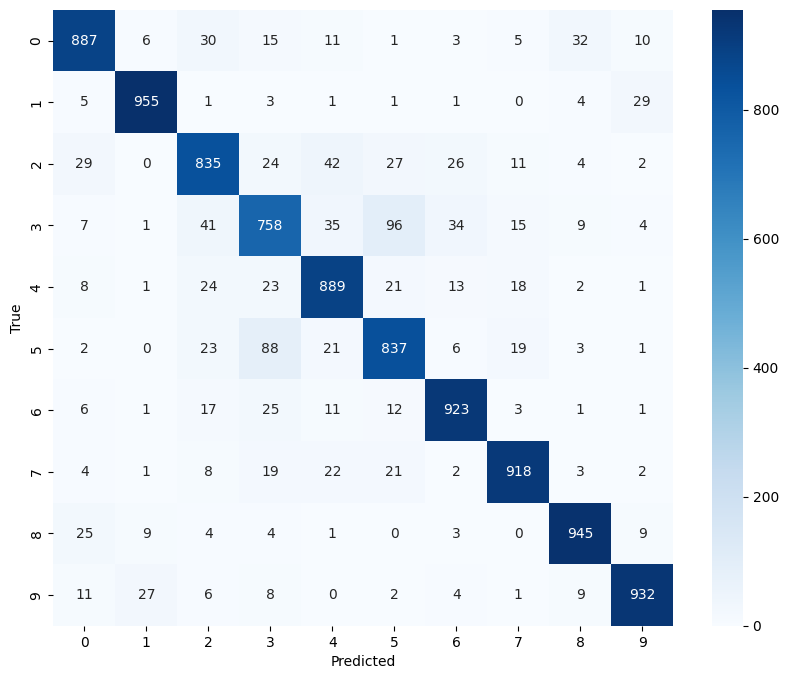

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for x, y in loader_test:
        x = x.to(device)
        y = y.to(device)
        scores = model(x)
        _, preds = scores.max(1)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.89      0.89      1000
           1       0.95      0.95      0.95      1000
           2       0.84      0.83      0.84      1000
           3       0.78      0.76      0.77      1000
           4       0.86      0.89      0.87      1000
           5       0.82      0.84      0.83      1000
           6       0.91      0.92      0.92      1000
           7       0.93      0.92      0.92      1000
           8       0.93      0.94      0.94      1000
           9       0.94      0.93      0.94      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



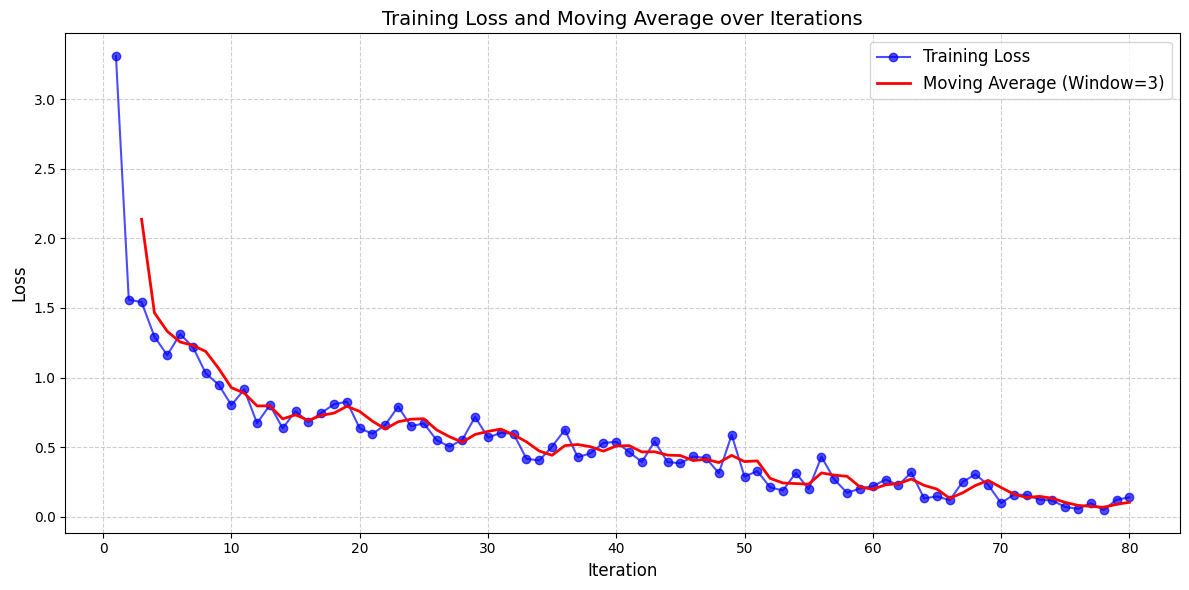

In [36]:
iterations = list(range(1, 8 * 10 + 1))
iteration_losses = [
    3.3087, 1.5598, 1.5409, 1.2939, 1.1604, 1.3119, 1.2193, 1.0303,  # Epoch 0
    0.9489, 0.8020, 0.9143, 0.6718, 0.8020, 0.6353, 0.7590, 0.6798,  # Epoch 1
    0.7462, 0.8072, 0.8267, 0.6360, 0.5953, 0.6600, 0.7916, 0.6501,  # Epoch 2
    0.6706, 0.5508, 0.5032, 0.5529, 0.7172, 0.5693, 0.6023, 0.5959,  # Epoch 3
    0.4165, 0.4044, 0.5043, 0.6249, 0.4274, 0.4565, 0.5297, 0.5383,  # Epoch 4
    0.4648, 0.3940, 0.5416, 0.3927, 0.3846, 0.4328, 0.4221, 0.3128,  # Epoch 5
    0.5875, 0.2886, 0.3278, 0.2111, 0.1886, 0.3152, 0.1986, 0.4310,  # Epoch 6
    0.2677, 0.1721, 0.2026, 0.2189, 0.2674, 0.2266, 0.3186, 0.1321,  # Epoch 7
    0.1458, 0.1194, 0.2500, 0.3044, 0.2283, 0.0981, 0.1596, 0.1568,  # Epoch 8
    0.1231, 0.1168, 0.0705, 0.0571, 0.0973, 0.0484, 0.1226, 0.1397,  # Epoch 9
]
window_size = 3
moving_average_losses = np.convolve(iteration_losses, np.ones(window_size)/window_size, mode='valid')
moving_average_iterations = list(range(window_size, len(iterations) + 1))
plt.figure(figsize=(12, 6))
plt.plot(iterations, iteration_losses, label='Training Loss', marker='o', linestyle='-', color='blue', alpha=0.7)
plt.plot(moving_average_iterations, moving_average_losses, label=f'Moving Average (Window={window_size})', color='red', linewidth=2)
plt.title('Training Loss and Moving Average over Iterations', fontsize=14)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()